In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
customer = pd.read_csv(r'../data\olist_customers_dataset.csv')
orders = pd.read_csv(r'../data\olist_orders_dataset.csv')
payments = pd.read_csv(r'../data\olist_order_payments_dataset.csv')
items = pd.read_csv(r'../data\olist_order_items_dataset.csv')
products = pd.read_csv(r'../data\olist_products_dataset.csv')

In [3]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

In [4]:
df = (orders.merge(customer, on= "customer_id").merge(payments, on="order_id").merge(items, on= "order_id"))

In [8]:
cust_ord = df.groupby("customer_unique_id")["order_id"].nunique()

In [23]:
rep_rate = ((cust_ord > 1).mean()) * 100
print("Доля возвращающихся покупателей: {}".format(round(rep_rate, 2)))

Доля возвращающихся покупателей: 3.05


In [ ]:
# Топ категорий по выручке

In [24]:
df_prod = df.merge(products, on="product_id")

In [27]:
df_prod.groupby("product_category_name")["payment_value"].sum().sort_values(ascending=False)

product_category_name
cama_mesa_banho                  1712553.67
beleza_saude                     1657373.12
informatica_acessorios           1585330.45
moveis_decoracao                 1430176.39
relogios_presentes               1429216.68
                                    ...    
pc_gamer                            2174.43
casa_conforto_2                     1710.54
cds_dvds_musicais                   1199.43
fashion_roupa_infanto_juvenil        785.67
seguros_e_servicos                   324.51
Name: payment_value, Length: 73, dtype: float64

In [ ]:
# Когортный анализ

In [36]:
cohort_df = orders.merge(customer, on= "customer_id")

In [37]:
cohort_df = cohort_df[cohort_df["order_status"] == "delivered"]

In [39]:
cohort_df["order_purchase_timestamp"] = pd.to_datetime(cohort_df["order_purchase_timestamp"])

In [40]:
cohort_df["order_month"] = cohort_df["order_purchase_timestamp"].dt.to_period("M")

In [42]:
cohort_df["cohort_month"] = (cohort_df.groupby("customer_unique_id")["order_month"].transform("min"))

In [44]:
cohort_df["period_number"] = (cohort_df["order_month"] - cohort_df["cohort_month"]).apply(lambda x: x.n)

In [46]:
cohort_data = (cohort_df.groupby(["cohort_month", "period_number"])["customer_unique_id"].nunique().reset_index())

In [49]:
cohort_pivot = cohort_data.pivot(index="cohort_month", columns="period_number", values="customer_unique_id")

In [54]:
cohort_pivot

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN
2017-03,2503.0,11.0,9.0,10.0,9.0,4.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN,NaN
2017-04,2256.0,14.0,5.0,4.0,6.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
2017-05,3451.0,16.0,16.0,10.0,10.0,11.0,14.0,5.0,9.0,9.0,9.0,12.0,8.0,1.0,6.0,7.0,NaN,NaN,NaN,NaN
2017-06,3037.0,15.0,12.0,13.0,9.0,12.0,11.0,7.0,4.0,6.0,9.0,11.0,5.0,5.0,7.0,NaN,NaN,NaN,NaN,NaN


In [55]:
retention = cohort_pivot.divide(cohort_pivot[0], axis=0)

In [80]:
retention.style.format("{:.2%}")

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.00%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%
2016-10,100.00%,nan%,nan%,nan%,nan%,nan%,0.38%,nan%,nan%,0.38%,nan%,0.38%,nan%,0.38%,nan%,0.38%,nan%,0.38%,0.76%,0.76%
2016-12,100.00%,100.00%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%
2017-01,100.00%,0.28%,0.28%,0.14%,0.42%,0.14%,0.42%,0.14%,0.14%,nan%,0.42%,0.14%,0.70%,0.42%,0.14%,0.14%,0.28%,0.42%,0.14%,nan%
2017-02,100.00%,0.18%,0.31%,0.12%,0.43%,0.12%,0.25%,0.18%,0.12%,0.18%,0.12%,0.31%,0.12%,0.18%,0.12%,0.06%,0.06%,0.18%,nan%,nan%
2017-03,100.00%,0.44%,0.36%,0.40%,0.36%,0.16%,0.16%,0.32%,0.32%,0.08%,0.36%,0.12%,0.20%,0.12%,0.16%,0.24%,0.08%,0.12%,nan%,nan%
2017-04,100.00%,0.62%,0.22%,0.18%,0.27%,0.27%,0.35%,0.31%,0.31%,0.18%,0.27%,0.09%,0.04%,0.04%,0.09%,0.09%,0.13%,nan%,nan%,nan%
2017-05,100.00%,0.46%,0.46%,0.29%,0.29%,0.32%,0.41%,0.14%,0.26%,0.26%,0.26%,0.35%,0.23%,0.03%,0.17%,0.20%,nan%,nan%,nan%,nan%
2017-06,100.00%,0.49%,0.40%,0.43%,0.30%,0.40%,0.36%,0.23%,0.13%,0.20%,0.30%,0.36%,0.16%,0.16%,0.23%,nan%,nan%,nan%,nan%,nan%


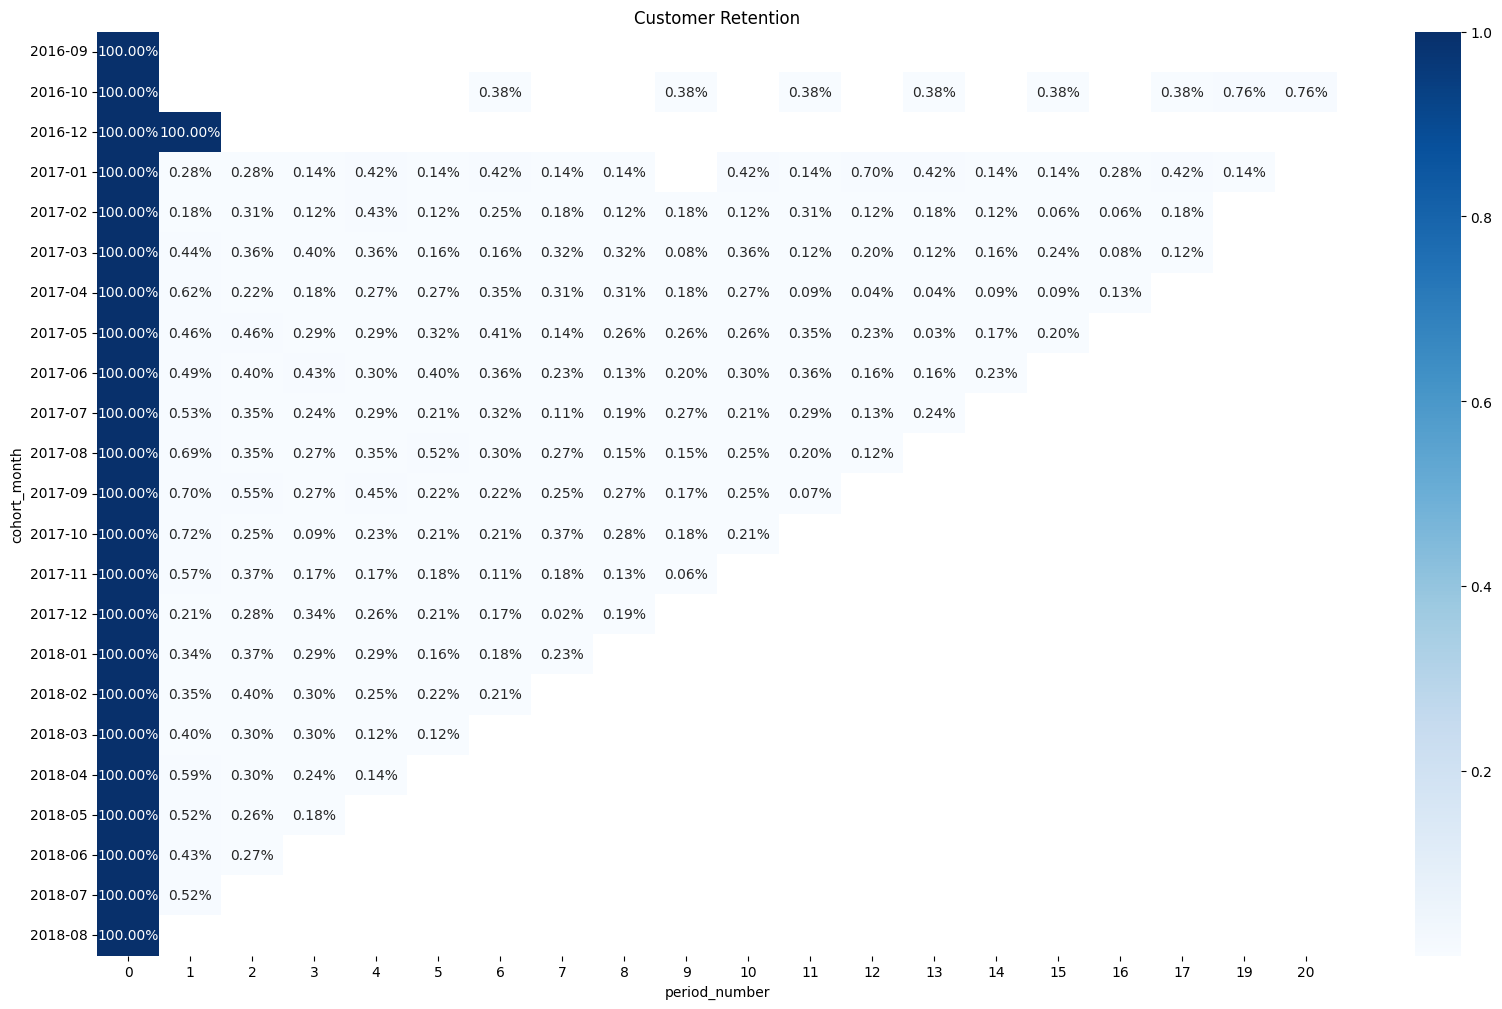

In [84]:
plt.figure(figsize= (20,12))

sns.heatmap(retention, annot=True, fmt=".2%", cmap="Blues")

plt.title("Customer Retention")
plt.show()